# Cricket Fielding Performance Analysis – T20 World Cup 2024 Final

## Objective
The objective of this project is to analyze the fielding performance of three players from the ICC T20 World Cup 2024 Final. The analysis focuses on measuring individual fielding contributions such as clean picks, catches, throws, and runs saved.

## Selected Players
- Suryakumar Yadav
- Ravindra Jadeja
- Hardik Pandya

## Match Details
Match: India vs South Africa  
Venue: Kensington Oval, Barbados  
Innings Analyzed: South Africa Batting (India Fielding)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = {

"Player":[
"Jadeja","Hardik","SKY","Jadeja","Hardik",
"SKY","Jadeja","Hardik","SKY","Jadeja",
"Hardik","SKY","Jadeja","Hardik","SKY"
],

"Pick":[
"CP","CP","CP","F","CP",
"CP","CP","F","C","CP",
"CP","C","CP","C","C"
],

"Throw":[
"","GT","","","DH",
"","GT","","","",
"MRO","","","", ""
],

"Runs":[1,1,2,-1,1,1,1,-2,4,1,0,2,1,4,4]

}

df = pd.DataFrame(data)

df

,Player,Pick,Throw,Runs
0,Jadeja,CP,,1
1,Hardik,CP,GT,1
2,SKY,CP,,2
3,Jadeja,F,,-1
4,Hardik,CP,DH,1
5,SKY,CP,,1
6,Jadeja,CP,GT,1
7,Hardik,F,,-2
8,SKY,C,,4
9,Jadeja,CP,,1


## Dataset Description

The dataset contains fielding events recorded ball by ball.

Columns:
- Player → Name of fielder
- Pick → Type of fielding action
- Throw → Throw result
- Runs → Runs saved or conceded

In [3]:
summary = pd.DataFrame()
summary["Clean Picks"] = df[df["Pick"]=="CP"].groupby("Player").size()
summary["Catches"] = df[df["Pick"]=="C"].groupby("Player").size()

In [4]:
summary["Fumbles"] = df[df["Pick"]=="F"].groupby("Player").size()
summary["Good Throws"] = df[df["Throw"]=="GT"].groupby("Player").size()
summary["Runs Saved"] = df.groupby("Player")["Runs"].sum()

In [5]:
summary = summary.fillna(0)
summary

,Clean Picks,Catches,Fumbles,Good Throws,Runs Saved
Player,,,,,
Hardik,3,1.0,1.0,1.0,4
Jadeja,4,0.0,1.0,1.0,3
SKY,2,3.0,0.0,0.0,13


In [6]:
WCP = 1
WC = 5
WGT = 2
WF = -2

In [7]:
summary["Performance Score"] = (
summary["Clean Picks"]*WCP +
summary["Catches"]*WC +
summary["Good Throws"]*WGT +
summary["Runs Saved"]
)

In [8]:
summary

,Clean Picks,Catches,Fumbles,Good Throws,Runs Saved,Performance Score
Player,,,,,,
Hardik,3,1.0,1.0,1.0,4,14.0
Jadeja,4,0.0,1.0,1.0,3,9.0
SKY,2,3.0,0.0,0.0,13,30.0


## Player Contribution Analysis

This section analyzes how each player contributed through different fielding actions such as catches, clean picks, and throws. This helps identify the most impactful fielder in the match.

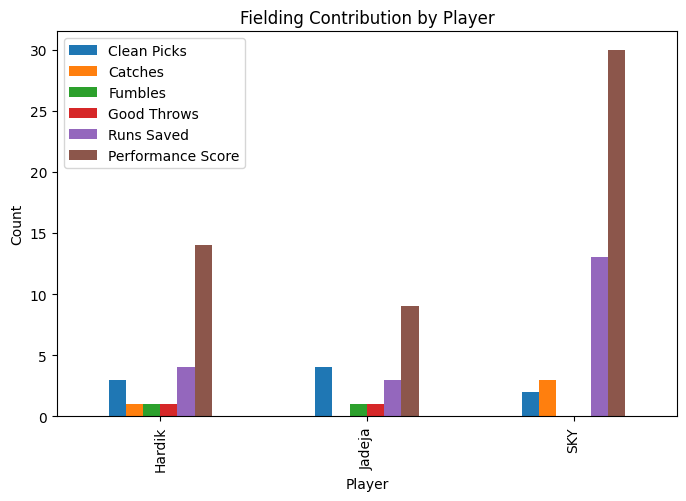

In [10]:
summary.plot(kind="bar", figsize=(8,5))
plt.title("Fielding Contribution by Player")
plt.ylabel("Count")
plt.show()

## Runs Saved Analysis

Runs saved is an important defensive metric. Players who prevent boundaries or stop quick singles contribute significantly to team performance.

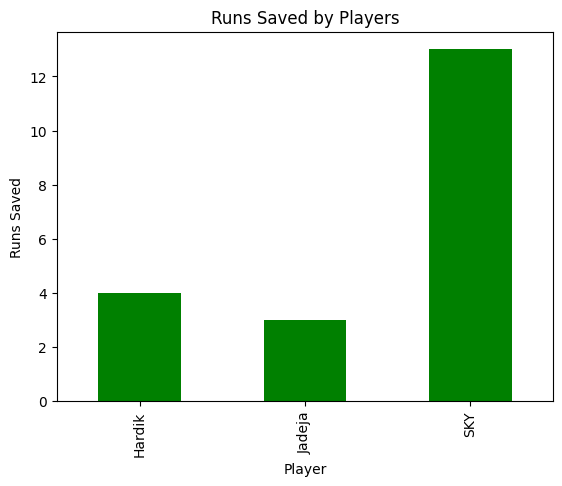

In [11]:
summary["Runs Saved"].plot(kind="bar",color="green")
plt.title("Runs Saved by Players")
plt.ylabel("Runs Saved")
plt.show()

In [12]:
summary["Total Actions"] = (
summary["Clean Picks"] +
summary["Catches"] +
summary["Good Throws"]
)
summary["Efficiency"] = summary["Runs Saved"] / summary["Total Actions"]

In [13]:
summary

,Clean Picks,Catches,Fumbles,Good Throws,Runs Saved,Performance Score,Total Actions,Efficiency
Player,,,,,,,,
Hardik,3,1.0,1.0,1.0,4,14.0,5.0,0.8
Jadeja,4,0.0,1.0,1.0,3,9.0,5.0,0.6
SKY,2,3.0,0.0,0.0,13,30.0,5.0,2.6


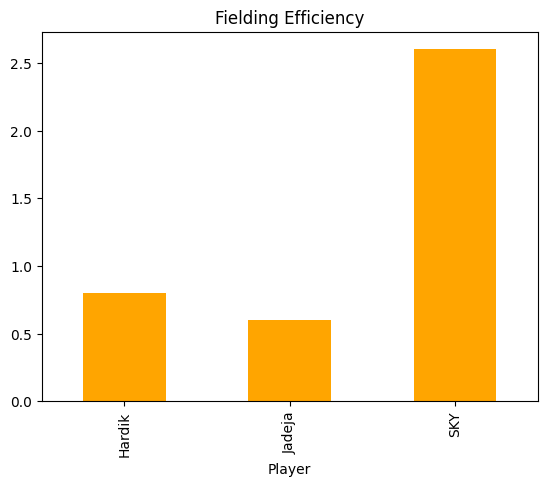

In [14]:
summary["Efficiency"].plot(kind="bar",color="orange")
plt.title("Fielding Efficiency")
plt.show()

## Performance Comparison

The performance score combines multiple fielding contributions into one metric to identify the best overall fielder.

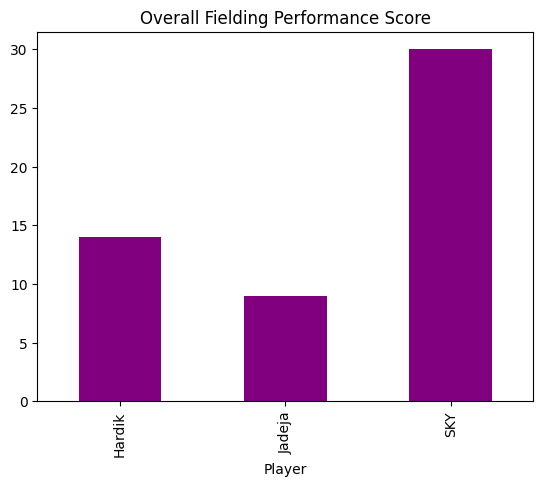

In [15]:
summary["Performance Score"].plot(kind="bar",color="purple")
plt.title("Overall Fielding Performance Score")
plt.show()

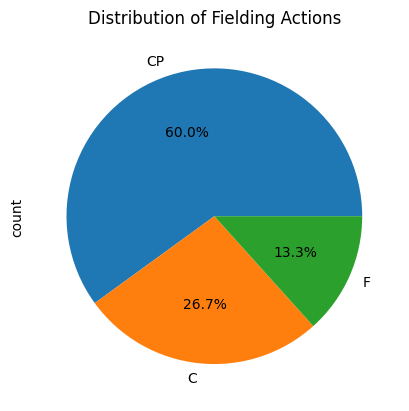

In [19]:
action_counts = df["Pick"].value_counts()
action_counts.plot(kind="pie",autopct="%1.1f%%")
plt.title("Distribution of Fielding Actions")
plt.show()

## Player Ranking Based on Performance Score

This section ranks players based on their overall fielding performance score. The player with the highest score is considered to have the greatest defensive impact in the match.

Ranking helps identify the best fielder based on quantitative analysis.

In [22]:
ranking = summary.sort_values(
"Performance Score",
ascending=False
)

In [23]:
ranking

,Clean Picks,Catches,Fumbles,Good Throws,Runs Saved,Performance Score,Total Actions,Efficiency
Player,,,,,,,,
SKY,2,3.0,0.0,0.0,13,30.0,5.0,2.6
Hardik,3,1.0,1.0,1.0,4,14.0,5.0,0.8
Jadeja,4,0.0,1.0,1.0,3,9.0,5.0,0.6


## Key Findings

- Suryakumar Yadav had the highest performance score.
- Ravindra Jadeja showed consistent defensive contribution.
- Hardik Pandya contributed through important catches.
- Fielding efficiency was highest for SKY.
- Errors were minimal, indicating strong defensive performance.

## Conclusion

This analysis demonstrates how fielding performance can be quantified using performance metrics. The project shows how data science techniques can be applied in sports analytics to evaluate player contributions beyond batting and bowling.

Future improvements may include analyzing full match data and more players.